In [51]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings



warnings.filterwarnings('ignore')

In [52]:
# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['avg_snr','min_snr','max_residual','x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [53]:

# --- 5. MAIN EXECUTION ---

spp_filepath = r'F:\zizo\RTKCorrection\src\research\data\test\SPP_BDS.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\data\test\Kinematic_BDS.csv'
    # 1) step is to return merged data
unified_df, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df)

✓ SPP file loaded with 7962 rows.
✓ Kinematic file loaded with 7930 rows.


7919

In [54]:
# --- 2. MODEL TRAINING AND EVALUATION ---

def train_ensemble_and_evaluate(unified_df, feature_cols):
    # --- Data prep ---
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    # --- Train Random Forest Regressor ---
    print(f"\n{'='*80}\nTraining Random Forest Regressor\n{'='*80}")
    
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_scaled, y_train_scaled)

    # --- Make predictions ---
    y_pred_scaled = rf_model.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    # ➡️ Extracts the raw NumPy array from the DataFrame
    y_test_vals = y_test.values

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: RANDOM FOREST MODEL\n" + "="*80)
    per_axis_rmse = []
    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(f"--- Axis {axis} ---\n  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n  RMSE (m): {rmse:.4f}\n")

    overall_rmse = np.mean(per_axis_rmse)
    print(f"Overall mean RMSE (m): {overall_rmse:.4f}")

    # --- Plot feature importance ---
    plt.figure(figsize=(10, 6))
    feature_importance = rf_model.feature_importances_
    indices = np.argsort(feature_importance)[::-1]
    
    plt.title("Random Forest Feature Importance",fontsize=18)
    plt.bar(range(len(feature_importance)), feature_importance[indices],color='skyblue')
    plt.xticks(range(len(feature_importance)), [feature_cols[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

    return rf_model, x_scaler, y_scaler, X_test, y_pred




In [55]:
# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error from diff_x, diff_y, diff_z
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.mean()

    # Corrected 3D Error = x_x + correction using AI
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    # overall error for improvement_distnace = testing_kinematic -  Corrected 3D Error
    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.mean()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

In [56]:
unified_df[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,7919.000000,7919.000000,7919.000000
mean,-1.530400,-11.705169,-10.303990
std,2.246325,8.899406,3.202905
min,-18.432200,-97.375500,-47.290700
25%,-2.639600,-13.981200,-11.320600
50%,-1.672300,-10.231600,-9.645900
75%,-0.587600,-7.155950,-8.557400
max,36.715900,27.579000,2.675500


In [65]:
from sklearn.ensemble import IsolationForest

# Ensure diff columns exist
cols = ['diff_x', 'diff_y', 'diff_z']
missing = [c for c in cols if c not in unified_df.columns]
if missing:
    raise KeyError(f'Missing required diff columns in unified_df: {missing}')

# Handle NaNs directly in unified_df (fill with median)
unified_df[cols] = unified_df[cols].fillna(unified_df[cols].median())

# Train IsolationForest on the diff columns
iso = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(unified_df[cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
unified_df['anomaly'] = iso.predict(unified_df[cols])

# Print summary
print('Anomaly value counts (1 = normal, -1 = anomaly):')
print(unified_df['anomaly'].value_counts())


Anomaly value counts (1 = normal, -1 = anomaly):
anomaly
 1    3981
-1    1362
Name: count, dtype: int64


In [66]:
unified_df = unified_df[unified_df['anomaly'] == 1].drop(columns=['anomaly'])
print(f"Data size before cleaning: {len(unified_df)}")

Data size before cleaning: 3981


In [67]:
unified_df[['diff_x', 'diff_y', 'diff_z']].describe()

,diff_x,diff_y,diff_z
count,3981.000000,3981.000000,3981.000000
mean,-1.686872,-9.668358,-9.452353
std,0.909865,2.539820,1.090074
min,-3.632600,-16.303000,-12.035100
25%,-2.334200,-11.369900,-10.304100
50%,-1.723800,-9.595300,-9.282300
75%,-1.146100,-7.751100,-8.646000
max,0.913100,-3.935400,-7.249100



Training Random Forest Regressor

FINAL EVALUATION: RANDOM FOREST MODEL
--- Axis X ---
  R² Score: 0.5584
  RMSE (m): 0.5667

--- Axis Y ---
  R² Score: 0.7306
  RMSE (m): 1.2914

--- Axis Z ---
  R² Score: 0.8404
  RMSE (m): 0.4410

Overall mean RMSE (m): 0.7664


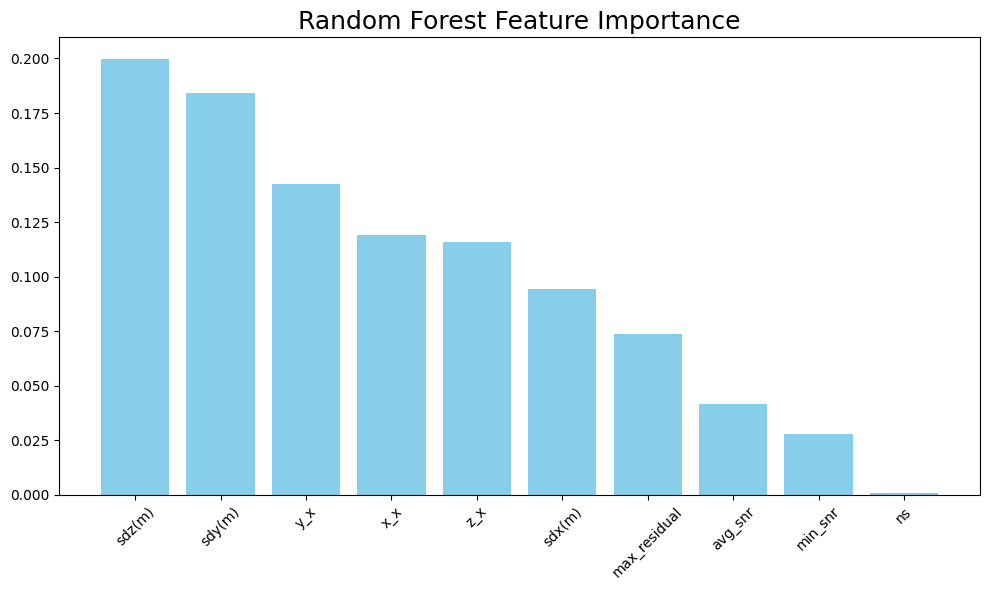


MODEL ACCURACY IMPROVEMENT ANALYSIS
Mean 3D Error (Original): 13.7520 m
Mean 3D Error (Corrected): 0.9086 m

Improvement: 12.8434 m (93.39%)


'\njoblib.dump(best_models, \'best_gnss_model.joblib\')\njoblib.dump(x_scaler, \'x_scaler.joblib\')\njoblib.dump(y_scaler, \'y_scaler.joblib\')\njoblib.dump(feature_cols, \'feature_cols.joblib\')\nprint("\n✓ Best model, scaler, and feature list saved successfully!")\nprint("\n✓ Analysis complete!")'

In [68]:
    # 2) train simple Neural Network (BatchNorm + Dropout)
    # Think of it like asking multiple experts for their opinion and averaging their answers.
best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(unified_df, feature_cols)
test_df = unified_df.loc[X_test.index]

calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))
"""
    joblib.dump(best_models, 'best_gnss_model.joblib')
    joblib.dump(x_scaler, 'x_scaler.joblib')
    joblib.dump(y_scaler, 'y_scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")"""